# Prediksi Resistensi Fenotipe dalam setiap Antibiotik terhadap Bakteri

## Abstraksi

## Import Library

In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from utilities.utility import AMRDataPipeline
from imblearn.over_sampling import SMOTE

from scipy.spatial.distance import squareform, pdist
from Bio.Phylo.TreeConstruction import DistanceTreeConstructor, DistanceMatrix
from Bio import Phylo

RANDOM_STATE = 42

### Helper Function

In [141]:
def notebook_visualize_unitigs_over_time(X_original, metadata_path, fitur_terpilih, antibiotic_col='azm', unitigs=5):
    meta = pd.read_csv(metadata_path)
    meta = meta.dropna(subset=[f'{antibiotic_col}_sr'])
    meta[f'{antibiotic_col}_sr'] = meta[f'{antibiotic_col}_sr'].astype(int)
    meta = meta[meta[f'{antibiotic_col}_sr'].isin([0, 1])]
    meta.set_index('Sample_ID', inplace=True)
    
    unitigs_sequences = fitur_terpilih[:unitigs]
    
    unitig_time_df = X_original[unitigs_sequences].join(meta[['Year', f'{antibiotic_col}_sr']], how="inner")
    
    unitig_filtered_resistance_df = unitig_time_df[unitig_time_df[f'{antibiotic_col}_sr'] == 1]
    unitig_filtered_succeptible_df = unitig_time_df[unitig_time_df[f'{antibiotic_col}_sr'] == 0]

    unitig_mean_resistance = unitig_filtered_resistance_df.groupby('Year').mean().sort_index()
    unitig_mean_succeptible = unitig_filtered_succeptible_df.groupby('Year').mean().sort_index()
    
    plt.figure(figsize=(12, 6))
    plt.title(f"Unitig Sequence Trajectory of Gonorhea ({antibiotic_col.upper()})")

    for unitig in unitigs_sequences:
        line, = plt.plot(unitig_mean_resistance.index, unitig_mean_resistance[unitig], marker='o', linestyle='-', alpha=1.0, label=f"{unitig[:10]}... (Resistant)")
        shared_color = line.get_color()
        plt.plot(unitig_mean_succeptible.index, unitig_mean_succeptible[unitig], marker='x', linestyle='--', alpha=0.3, color=shared_color, label=f"{unitig[:10]}... (Susceptible)")

    plt.grid(True, alpha=0.5, linestyle='--')
    plt.ylabel("Unitig Frequency")
    plt.xlabel("Timeline")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [142]:
def notebook_visualize_phylo_tree(X_clean, y, unitigs=15, mode='ascii', type='resistant'):
    df_temp = X_clean.copy()
    df_temp['target'] = y
    
    if type == 'resistant':
        df = df_temp[df_temp['target'] == 1].iloc[:unitigs].drop(columns=['target'])
    elif type == 'succeptible':
        df = df_temp[df_temp['target'] == 0].iloc[:unitigs].drop(columns=['target'])
    else:
        raise ValueError(f"{type} is not supported.")\
    
    names = [str(name) for name in df.index.tolist()]
    dense_matrix = squareform(pdist(df.values, metric='jaccard'))
    
    biopython_matrix = []
    for i in range(len(names)):
        row = list(dense_matrix[i, :i+1])
        biopython_matrix.append(row)

    dm = DistanceMatrix(names=names, matrix=biopython_matrix)
    constructor = DistanceTreeConstructor()
    tree = constructor.nj(dm)
    
    if mode == 'plt':
        plt.figure(figsize=(20, 12))
        Phylo.draw(tree, do_show=False)
        plt.title(f"Phylogenetic Tree - {type.capitalize()} Samples")
        plt.show()
    elif mode == 'ascii':
        Phylo.draw_ascii(tree)
    

# 3. Train/Test Split, 80% untuk Training, Sisanya untuk Testing

In [143]:
X = pd.read_csv("data/azm_features.csv", sep="\t").set_index("Sample_ID")
y = pd.read_csv("data/azm_labels.csv", sep="\t").set_index("Sample_ID").squeeze()


In [144]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.5, random_state=RANDOM_STATE, stratify=y_test
)
print(f"\nTraining set : {X_train.shape[0]} rows")
print(f"Validation set : {X_val.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")


Training set : 2782 rows
Validation set : 348 rows
Test set     : 348 rows


# 4. Data Preprocessing

### Handling Imbalanced Dataset

In [145]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"\nResampled training set : {X_train_resampled.shape[0]} rows") 



Resampled training set : 4848 rows


### Random Forest Feature Selection

In [146]:
n_features_to_select = 100
rf_selector = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)
rf_selector.fit(X_train, y_train)
rf_feature_importances = pd.Series(rf_selector.feature_importances_, index=X_train.columns)
rf_top_features = rf_feature_importances.nlargest(n_features_to_select).index

X_train_selected = X_train_resampled[rf_top_features]
X_val_selected = X_val[rf_top_features]
X_test_selected = X_test[rf_top_features]


# 5. Model Training

### Random Forest Classifier

In [147]:
rf_model = RandomForestClassifier(
    n_estimators=250,         
    max_depth=8,               
    class_weight='balanced',   
    random_state=RANDOM_STATE,
    n_jobs=-1                  
)
rf_model.fit(X_train_selected, y_train_resampled)
y_val_pred_rf = rf_model.predict(X_val_selected)


In [148]:

print("Random Forest Validation Accuracy:", accuracy_score(y_val, y_val_pred_rf))
print("Classification Report:\n", classification_report(y_val, y_val_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred_rf))

print("True Class:\n", y_val.value_counts())

print("Predicted Class:\n", pd.Series(y_val_pred_rf).value_counts())


Random Forest Validation Accuracy: 0.9626436781609196
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       303
           1       0.86      0.84      0.85        45

    accuracy                           0.96       348
   macro avg       0.92      0.91      0.92       348
weighted avg       0.96      0.96      0.96       348

Confusion Matrix:
 [[297   6]
 [  7  38]]
True Class:
 azm_sr
0    303
1     45
Name: count, dtype: int64
Predicted Class:
 0    304
1     44
Name: count, dtype: int64


### Support Vector Machine

In [149]:
sv_model = SVC(
    kernel='rbf',              
    C=1.0,                    
    class_weight='balanced',   
    random_state=RANDOM_STATE
)
sv_model.fit(X_train_selected, y_train_resampled)
y_val_pred_sv = sv_model.predict(X_val_selected)



In [150]:
print("SVM Validation Accuracy:", accuracy_score(y_val, y_val_pred_sv))
print("Classification Report:\n", classification_report(y_val, y_val_pred_sv))
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred_sv))

print("True Class:\n", y_val.value_counts())

print("Predicted Class:\n", pd.Series(y_val_pred_sv).value_counts())

SVM Validation Accuracy: 0.9683908045977011
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       303
           1       0.83      0.96      0.89        45

    accuracy                           0.97       348
   macro avg       0.91      0.96      0.93       348
weighted avg       0.97      0.97      0.97       348

Confusion Matrix:
 [[294   9]
 [  2  43]]
True Class:
 azm_sr
0    303
1     45
Name: count, dtype: int64
Predicted Class:
 0    296
1     52
Name: count, dtype: int64


### XGBoost

In [151]:
xgb_model = XGBClassifier(
    n_estimators=250,
    max_depth=8,
    scale_pos_weight=1,
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train_selected, y_train_resampled)
y_val_pred_xgb = xgb_model.predict(X_val_selected)




d:\Data\Kuliah\Tingkat 2\Others\Coding\DatSci\IF3221_Tugas-Besar_Kelompok-1_K3\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:57:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [152]:
print("XGBoost Validation Accuracy:", accuracy_score(y_val, y_val_pred_xgb))
print("Classification Report:\n", classification_report(y_val, y_val_pred_xgb)) 
print("Confusion Matrix:\n", confusion_matrix(y_val, y_val_pred_xgb))
print("True Class:\n", y_val.value_counts())

print("Predicted Class:\n", pd.Series(y_val_pred_xgb).value_counts())


XGBoost Validation Accuracy: 0.9597701149425287
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98       303
           1       0.83      0.87      0.85        45

    accuracy                           0.96       348
   macro avg       0.90      0.92      0.91       348
weighted avg       0.96      0.96      0.96       348

Confusion Matrix:
 [[295   8]
 [  6  39]]
True Class:
 azm_sr
0    303
1     45
Name: count, dtype: int64
Predicted Class:
 0    301
1     47
Name: count, dtype: int64


# 6. Visualization on Evaluation

### Visualization Unitigs Over The Years 

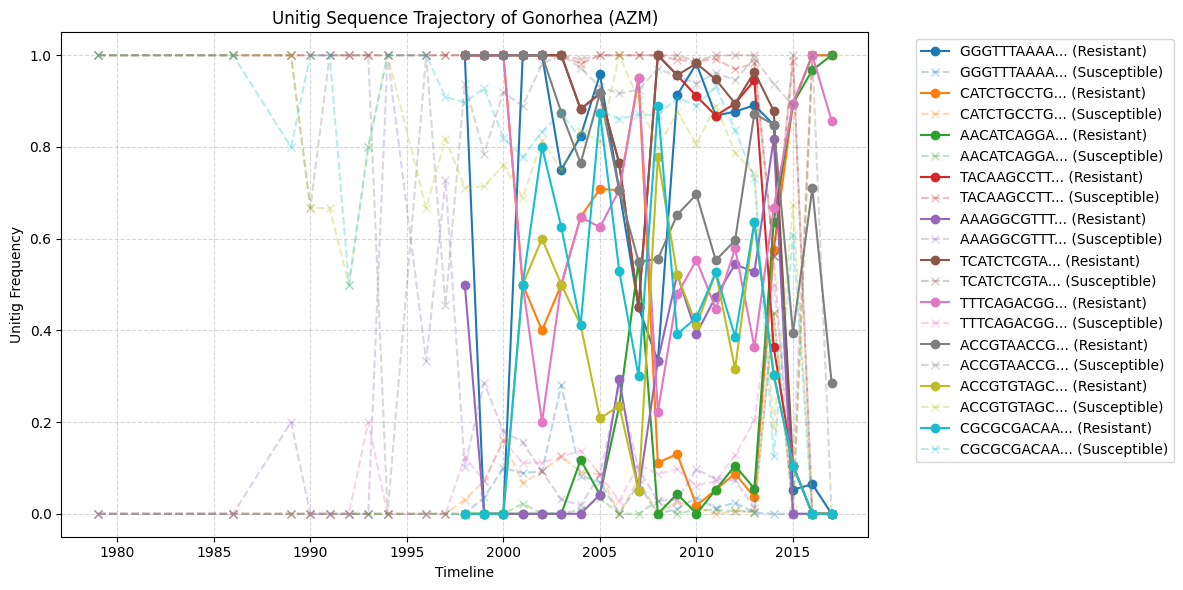

In [153]:
notebook_visualize_unitigs_over_time(
    X_original=X, 
    metadata_path="data/metadata.csv", 
    fitur_terpilih=rf_top_features, 
    antibiotic_col='azm', 
    unitigs=10 
)

### Visualization Phylo Tree

In [154]:
notebook_visualize_phylo_tree(
    X_clean=X_train_selected, 
    y=y_train_resampled, 
    unitigs=50,       
    mode='ascii',   
    type='resistant'  
)

           ___ 385
         ,|
      ___||_____ 277
     |   |
    ,|   |____ 122
    ||
    || , 233
    ||_|
    |  | 102
    |
    |     _______ 239
    |    |
    |    |              __ 371
    |    |            ,|
    |    |            ||_______ 245
    |    |      ______|
   _|    |     |      |           , 320
  | |    |     |      |          _|
  | |    |     |      |_________| | 249
  | |    |     |                |
  | |    |     |                | 183
  | |    |     |
  | |    |    _|         _______________________ 117
  | |    |   | |        |
  | |    |   | |        |      ____________________ 398
  | |    |   | |        |     |
  | |    |   | |        |    _|      ________________ 64
  | |    |   | |        |   | |     |
  | |____|   | |        |   | |     |                  _______ 255
  |      |   | |________|   | |_____|                 |
  |      |   |          |   |       |                 |     , 285
  |      |   |          |   |       |                 |   __|
  |

# 7. Export Model

### Random Forest (The Best model)

In [ ]:


best_model = rf_model
joblib.dump(best_model, 'model/best_rf_model.pkl')

['model/best_rf_model.pkl']

### SVM Model

In [163]:
joblib.dump(sv_model, 'model/svm_model.pkl')

['model/svm_model.pkl']

### XGBoost Model

In [165]:
XGBoost_model = xgb_model
XGBoost_model.save_model('model/xgboost_model.json')


# 8. Load Model

In [166]:
load_model = joblib.load("model/best_rf_model.pkl")
y_pred = load_model.predict(X_test_selected)

print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("True Class:\n", y_test.value_counts())

print("Predicted Class:\n", pd.Series(y_val_pred_xgb).value_counts())


Random Forest Test Accuracy: 0.9540229885057471
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97       304
           1       0.85      0.77      0.81        44

    accuracy                           0.95       348
   macro avg       0.91      0.88      0.89       348
weighted avg       0.95      0.95      0.95       348

Confusion Matrix:
 [[298   6]
 [ 10  34]]
True Class:
 azm_sr
0    304
1     44
Name: count, dtype: int64
Predicted Class:
 0    301
1     47
Name: count, dtype: int64
